In [1]:
if (!requireNamespace("ggalluvial", quietly = TRUE)) {
  install.packages("ggalluvial")
}

suppressPackageStartupMessages({library(ggplot2)
library(ggalluvial)
library(dplyr)
library(RColorBrewer)
library(gridExtra)
library(rlang)
library(stringr)
library(patchwork)
})

In [2]:
source('../utilities/functions/label-and-color-maps.R')

In [3]:
create_split_plot <- function(df, label_column, title, rare_threshold = 0.005) {
  # Shared setup
  df <- df %>%
    group_by(label.visitDetails) %>%
    mutate(norm_per_visit = frequency / sum(frequency))
  levels_order <- c(
    "PreTx", "PI2C", "EI",
    "ASCT60d", "ASCT90d", "ASCT1y", "ASCT2y",
    "Healthy"
  )
  present_levels <- levels_order[levels_order %in% unique(df$label.visitDetails)]
  df$label.visitDetails <- factor(df$label.visitDetails, levels = present_levels)

  # Classify rare types 
  mean_freq <- df %>%
    group_by(!!sym(label_column)) %>%
    summarise(mean_freq = mean(norm_per_visit, na.rm = TRUE), .groups = "drop")
  rare_types <- mean_freq %>% filter(mean_freq <= rare_threshold) %>% pull(!!sym(label_column))
  major_types <- mean_freq %>% filter(mean_freq > rare_threshold) %>% pull(!!sym(label_column))

  # Main plot (rare collapsed)
  df_main <- df %>%
    mutate(!!label_column := ifelse(
      !!sym(label_column) %in% rare_types,
      "Rare Cell Types",
      !!sym(label_column)
    )) %>%
    group_by(label.visitDetails, !!sym(label_column)) %>%
    summarise(frequency = sum(frequency), .groups = "drop") %>%
    group_by(label.visitDetails) %>%
    mutate(norm_per_visit = frequency / sum(frequency))

  l3_color_map[["Rare Cell Types"]] <- "gray40"
  cmap_order <- names(l3_color_map)
  present_main <- cmap_order[cmap_order %in% unique(df_main[[label_column]])]
  present_main <- c("Rare Cell Types", setdiff(present_main, "Rare Cell Types"))
  df_main[[label_column]] <- factor(df_main[[label_column]], levels = present_main)

  df_main_tx <- df_main %>% filter(label.visitDetails != "Healthy")

  p_main <- ggplot(df_main,
              aes(x = label.visitDetails, stratum = !!sym(label_column),
                  alluvium = !!sym(label_column), y = norm_per_visit,
                  fill = !!sym(label_column)))
  if (nrow(df_main_tx) > 0) {
    p_main <- p_main + geom_alluvium(data = df_main_tx, width = 0.1, alpha = 0.7)
  }
  p_main <- p_main +
    geom_stratum(width = 0.6) +
    scale_fill_manual(values = l3_color_map, breaks = present_main) +
    scale_x_discrete(drop = TRUE) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position   = "right",
      legend.margin      = margin(0, 10, 0, 0),
      legend.text        = element_text(size = 9),
      legend.key.size    = unit(0.35, "cm"),
      axis.text.x        = element_text(angle = 30, hjust = 1),
      plot.subtitle      = element_text(size = 11, face = "italic")
    ) +
    labs(x = "", y = "Normalized Frequency", ) +
    guides(fill = guide_legend(title = NULL, ncol = 1, byrow = FALSE))

  # Rare panel (expanded)
  df_rare <- df %>%
    filter(!!sym(label_column) %in% rare_types) %>%
    group_by(label.visitDetails, !!sym(label_column)) %>%
    summarise(frequency = sum(frequency), .groups = "drop") %>%
    group_by(label.visitDetails) %>%
    mutate(norm_per_visit = frequency / sum(frequency))

  present_rare <- cmap_order[cmap_order %in% unique(df_rare[[label_column]])]
  df_rare[[label_column]] <- factor(df_rare[[label_column]], levels = present_rare)

  df_rare_tx <- df_rare %>% filter(label.visitDetails != "Healthy")

  p_rare <- ggplot(df_rare,
              aes(x = label.visitDetails, stratum = !!sym(label_column),
                  alluvium = !!sym(label_column), y = norm_per_visit,
                  fill = !!sym(label_column)))
  if (nrow(df_rare_tx) > 0) {
    p_rare <- p_rare + geom_alluvium(data = df_rare_tx, width = 0.1, alpha = 0.7)
  }
  p_rare <- p_rare +
    geom_stratum(width = 0.6) +
    scale_fill_manual(values = l3_color_map, breaks = present_rare) +
    scale_x_discrete(drop = TRUE) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position   = "right",
      legend.margin      = margin(0, 10, 0, 0),
      legend.text        = element_text(size = 9),
      legend.key.size    = unit(0.35, "cm"),
      axis.text.x        = element_text(angle = 30, hjust = 1),
      plot.subtitle      = element_text(size = 11, face = "italic")
    ) +
    labs(x = "", y = NULL,
         subtitle = paste0("Rare cell types (n=", length(rare_types),
                          ", ≤", round(rare_threshold * 100, 2), "% mean freq)")) +
    guides(fill = guide_legend(title = NULL, ncol = 1, byrow = FALSE))

  # Combine
  combined <- wrap_plots(p_main, p_rare, nrow = 1) +
    plot_annotation(
      title = title,
      theme = theme(plot.title = element_text(face = "bold", size = 16))
    )

  return(combined)
}

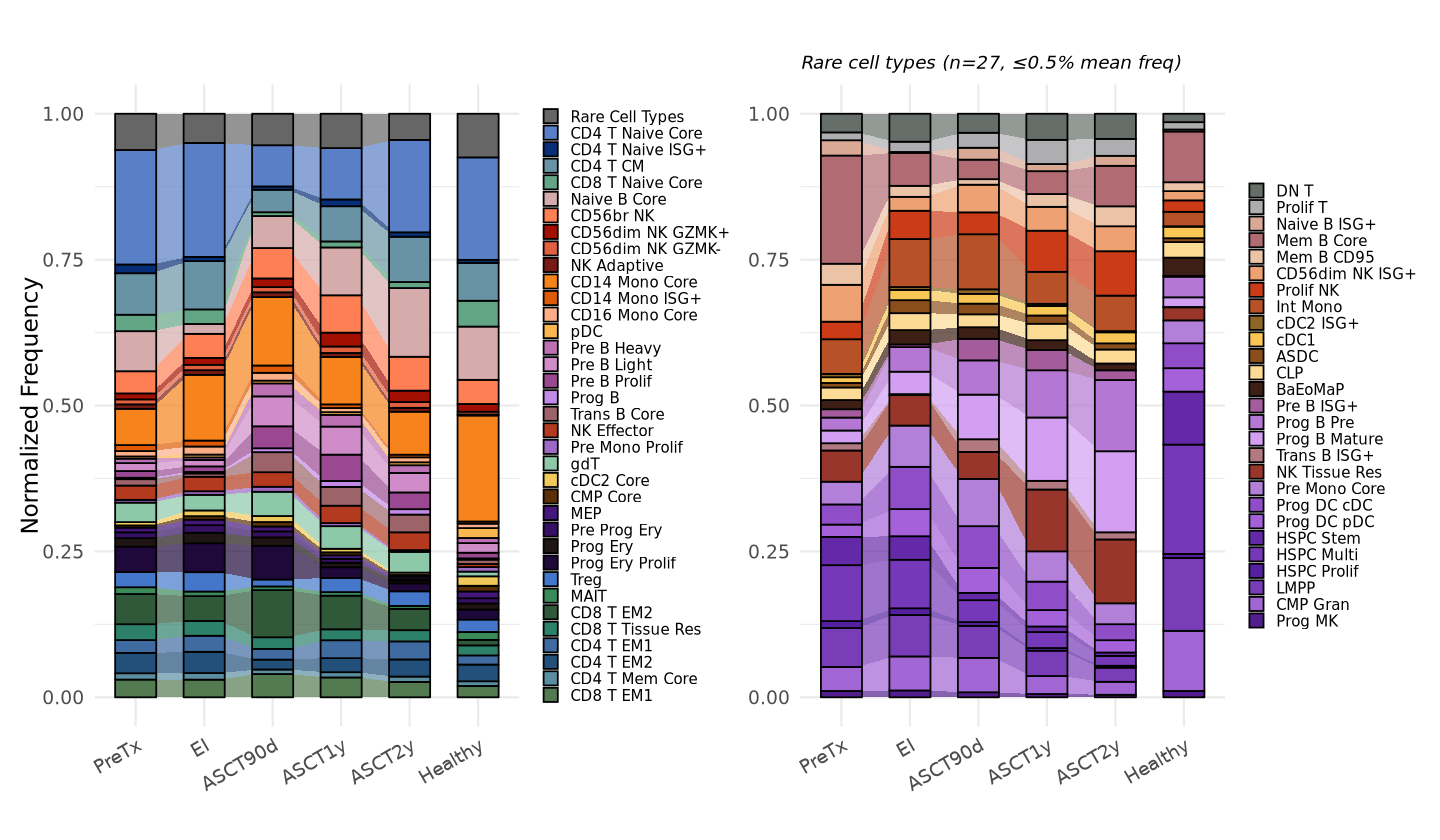

In [4]:
df_l3 <- read.csv('../../data/figure-inputs/frequency_files/bmmc_l3_frequency.csv')
df_l3 <- df_l3 %>%
  filter(label.visitDetails != "") %>%
  group_by(label.visitDetails, aifi_plot_l3) %>%
  summarise(frequency = sum(raw_frequency), .groups = "drop")

options(repr.plot.width = 12, repr.plot.height = 7) 
p <- create_split_plot(df_l3, 
                  "aifi_plot_l3", 
                  "", 
                  rare_threshold = 0.005)
p

In [5]:
ggsave("../../data/figure-outputs/supplementary-2/sup_2c.pdf", plot = p, width = 12, height = 6.5, dpi = 200, device = cairo_pdf)